In [26]:
import argparse
import inspect
import sys
import time
from pathlib import Path

import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader as TorchDataLoader, Subset

_here = Path.cwd()
_project_root = _here.parents[4]
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from galaxy_images.galaxy_model.contrastive_baseline.dual_encoder_contrastive import (
    DualEncoderContrastiveModule,
)
from galaxy_images.galaxy_model.neighbors import NeighborsSimpleDataset

In [ ]:
NEIGHBORS_HDF5 = "/data/vision/billf/scratch/pablomer/data/neighbours_v2.h5"
NEIGHBORS_START_INDEX = 70400
NEIGHBORS_COUNT = 80    00  # small count for quick testing; bump back to 8000 for full run
NEIGHBORS_SEED = 42
# SHUFFLE_NEIGHBORS = True


In [28]:
print(f"[Neighbors Debug] Loading neighbors dataset from: {NEIGHBORS_HDF5}")
full_dataset = NeighborsSimpleDataset(hdf5_path=NEIGHBORS_HDF5)
end_index = NEIGHBORS_START_INDEX + NEIGHBORS_COUNT

dataset = Subset(full_dataset, range(NEIGHBORS_START_INDEX, end_index))
print(
    "[Neighbors Debug] Slice configuration: "
    f"start={NEIGHBORS_START_INDEX}, count={NEIGHBORS_COUNT}, end_exclusive={end_index}"
)

[Neighbors Debug] Loading neighbors dataset from: /data/vision/billf/scratch/pablomer/data/neighbours_v2.h5
[Neighbors Debug] Slice configuration: start=70400, count=8000, end_exclusive=78400


In [29]:
im_hsc, im_legacy, metadata = dataset[0]

In [30]:
metadata.keys()

dict_keys(['idx', 'index_mmu', 'dec', 'healpix', 'hsc_g_cmodel_flux', 'hsc_g_cmodel_fluxerr', 'hsc_g_sdssshape_psf_shape11', 'hsc_g_sdssshape_psf_shape12', 'hsc_g_sdssshape_psf_shape22', 'hsc_i_cmodel_flux', 'hsc_i_cmodel_fluxerr', 'hsc_i_sdssshape_psf_shape11', 'hsc_i_sdssshape_psf_shape12', 'hsc_i_sdssshape_psf_shape22', 'hsc_i_variance_value', 'hsc_r_cmodel_flux', 'hsc_r_cmodel_fluxerr', 'hsc_r_sdssshape_psf_shape11', 'hsc_r_sdssshape_psf_shape12', 'hsc_r_sdssshape_psf_shape22', 'hsc_r_variance_value', 'hsc_z_cmodel_flux', 'hsc_z_cmodel_fluxerr', 'hsc_z_sdssshape_psf_shape11', 'hsc_z_sdssshape_psf_shape12', 'hsc_z_sdssshape_psf_shape22', 'hsc_z_variance_value', 'legacy_EBV', 'legacy_FLUX_G', 'legacy_FLUX_I', 'legacy_FLUX_IVAR_G', 'legacy_FLUX_IVAR_I', 'legacy_FLUX_IVAR_R', 'legacy_FLUX_IVAR_Z', 'legacy_FLUX_R', 'legacy_FLUX_Z', 'legacy_GALDEPTH_G', 'legacy_GALDEPTH_I', 'legacy_GALDEPTH_R', 'legacy_GALDEPTH_Z', 'legacy_NOBS_G', 'legacy_NOBS_I', 'legacy_NOBS_R', 'legacy_NOBS_Z', 'lega

In [31]:
metadata['idx'], metadata['index_mmu'], metadata['healpix']

(70400, 300849, 1702)

In [32]:
ra_list, dec_list, healpix_list = [], [], []
for i in range(len(dataset)):
    _, _, meta = dataset[i]
    ra_list.append(meta['ra'])
    dec_list.append(meta['dec'])
    healpix_list.append(meta['healpix'])

ra = np.array(ra_list)
dec = np.array(dec_list)
healpix = np.array(healpix_list)

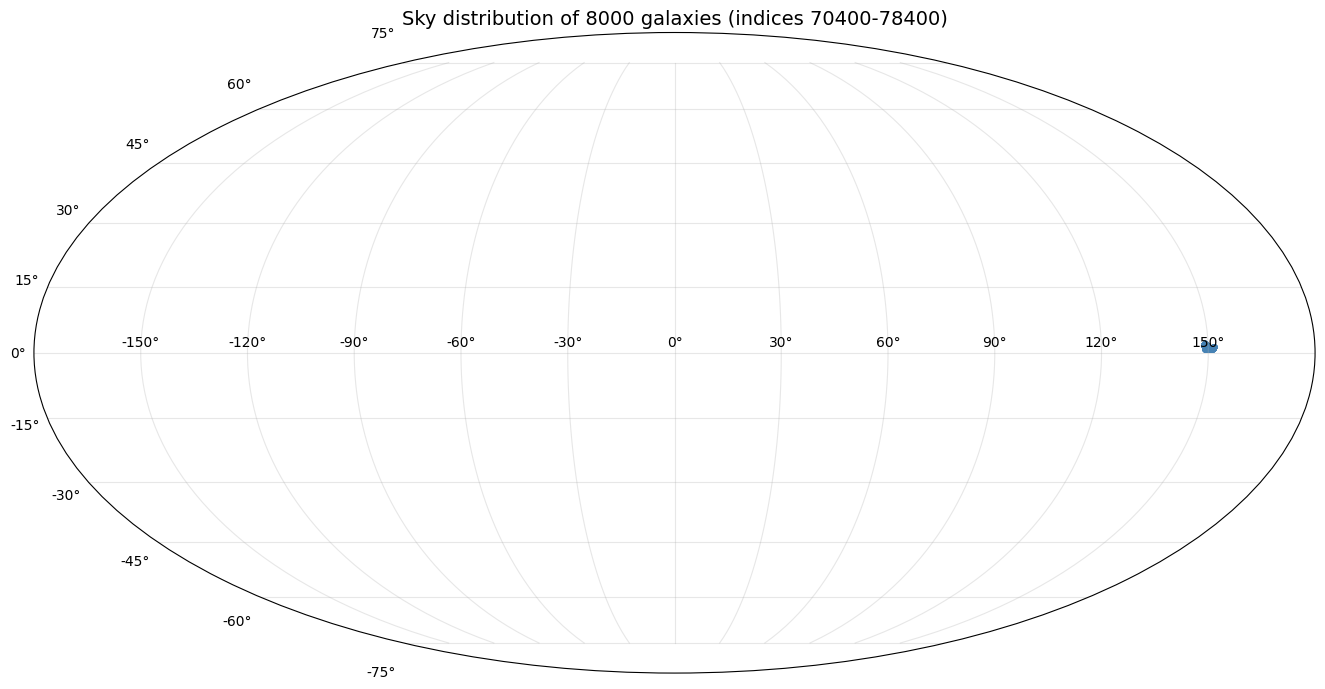

RA range: [148.5, 151.8]  Dec range: [0.7, 2.4]


In [33]:
import matplotlib.pyplot as plt

def to_mollweide(ra_deg, dec_deg):
    ra = np.deg2rad(ra_deg)
    ra = np.where(ra > np.pi, ra - 2 * np.pi, ra)
    dec = np.deg2rad(dec_deg)
    return ra, dec

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection='mollweide')

ra_t, dec_t = to_mollweide(ra, dec)

ax.scatter(ra_t, dec_t, s=3, alpha=0.8, c='steelblue', rasterized=True)

ax.set_title(f'Sky distribution of {NEIGHBORS_COUNT} galaxies (indices {NEIGHBORS_START_INDEX}-{NEIGHBORS_START_INDEX + NEIGHBORS_COUNT})', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sky_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"RA range: [{ra.min():.1f}, {ra.max():.1f}]  Dec range: [{dec.min():.1f}, {dec.max():.1f}]")